In [14]:

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
DATA_PATH = "house_data.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
# The raw file has NO header row and is whitespace-separated, so we supply
# the classic Boston Housing column names ourselves.
COLUMN_NAMES = [
    "CRIM",     # per capita crime rate by town
    "ZN",       # proportion of residential land zoned for large lots
    "INDUS",    # proportion of non-retail business acres per town
    "CHAS",     # Charles River dummy variable (1 if tract bounds river)
    "NOX",      # nitric oxide concentration
    "RM",       # average number of rooms per dwelling
    "AGE",      # proportion of owner-occupied units built before 1940
    "DIS",      # weighted distance to employment centers
    "RAD",      # index of accessibility to radial highways
    "TAX",      # property tax rate
    "PTRATIO",  # pupil-teacher ratio by town
    "B",        # proportion of Black residents by town (historical index)
    "LSTAT",    # % lower status of the population
    "MEDV",     # Median value of owner-occupied homes in $1000s (TARGET)
]

In [8]:
def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

In [9]:
# ===========================================================================
# LEVEL 1 - TASK 1 : DATA CLEANING AND PREPROCESSING
# ===========================================================================
section("LEVEL 1 - TASK 1: DATA CLEANING AND PREPROCESSING")

# 1. Load the dataset using pandas
df = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES, sep=r"\s+")
print(f"Dataset loaded. Shape: {df.shape}")
print(df.head())

# 2. Identify and handle missing values
print("\nMissing values per column BEFORE cleaning:")
print(df.isnull().sum())

# Impute any missing numeric values with the column median (robust to outliers)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("\nMissing values per column AFTER cleaning:", df.isnull().sum().sum())

# 3. Remove duplicate rows
duplicates_found = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDuplicate rows found and removed: {duplicates_found}")

# 4. Standardize inconsistent data formats
# CHAS and RAD are categorical/discrete flags - ensure correct integer dtype
df["CHAS"] = df["CHAS"].astype(int)
df["RAD"] = df["RAD"].astype(int)

# Ensure all remaining columns are proper floats (fixes any string/whitespace issues)
numeric_cols = [c for c in df.columns if c not in ["CHAS", "RAD"]]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna().reset_index(drop=True)

print("\nFinal cleaned dataset info:")
print(df.info())

cleaned_path = os.path.join(OUTPUT_DIR, "cleaned_house_data.csv")
df.to_csv(cleaned_path, index=False)
print(f"\nCleaned dataset saved to: {cleaned_path}")


LEVEL 1 - TASK 1: DATA CLEANING AND PREPROCESSING
Dataset loaded. Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Missing values per column BEFORE cleaning:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Missing values per column AFTER c


LEVEL 1 - TASK 2: EXPLORATORY DATA ANALYSIS (EDA)

Summary statistics (mean, std, min, max, mode):
               mean        50%       mode         std        min       max
CRIM       3.613524    0.25651    0.01501    8.601545    0.00632   88.9762
ZN        11.363636    0.00000    0.00000   23.322453    0.00000  100.0000
INDUS     11.136779    9.69000   18.10000    6.860353    0.46000   27.7400
CHAS       0.069170    0.00000    0.00000    0.253994    0.00000    1.0000
NOX        0.554695    0.53800    0.53800    0.115878    0.38500    0.8710
RM         6.284634    6.20850    5.71300    0.702617    3.56100    8.7800
AGE       68.574901   77.50000  100.00000   28.148861    2.90000  100.0000
DIS        3.795043    3.20745    3.49520    2.105710    1.12960   12.1265
RAD        9.549407    5.00000   24.00000    8.707259    1.00000   24.0000
TAX      408.237154  330.00000  666.00000  168.537116  187.00000  711.0000
PTRATIO   18.455534   19.05000   20.20000    2.164946   12.60000   22.0000


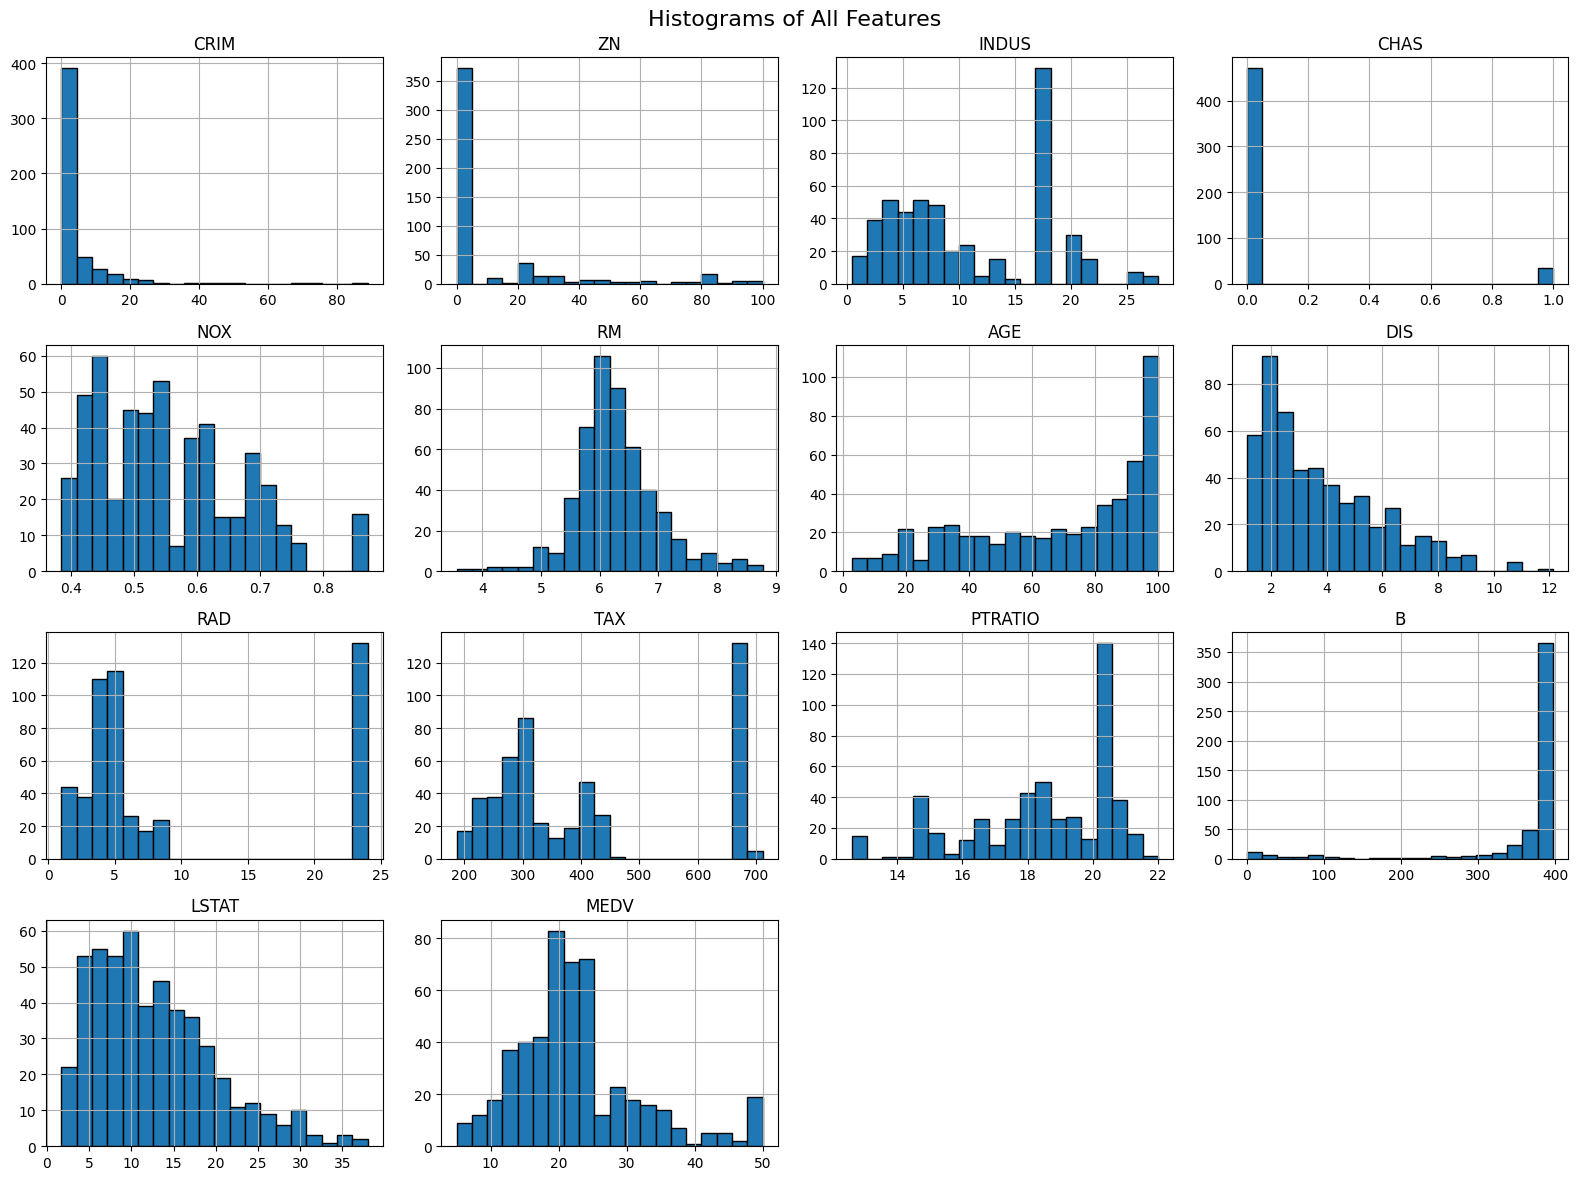

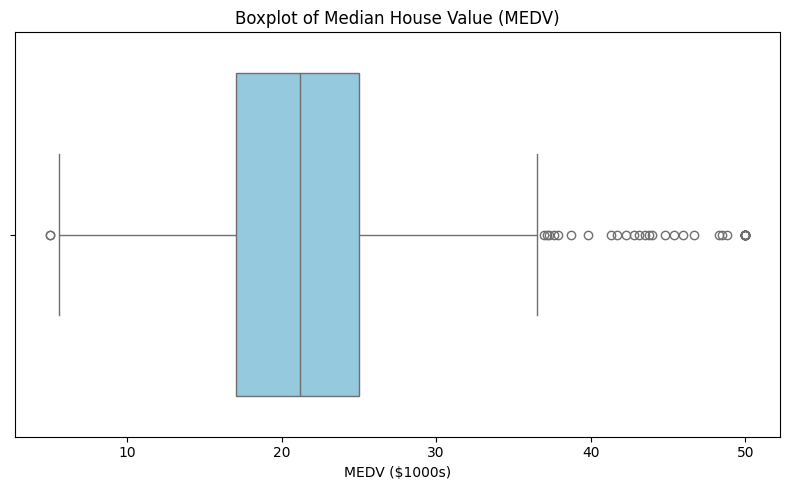

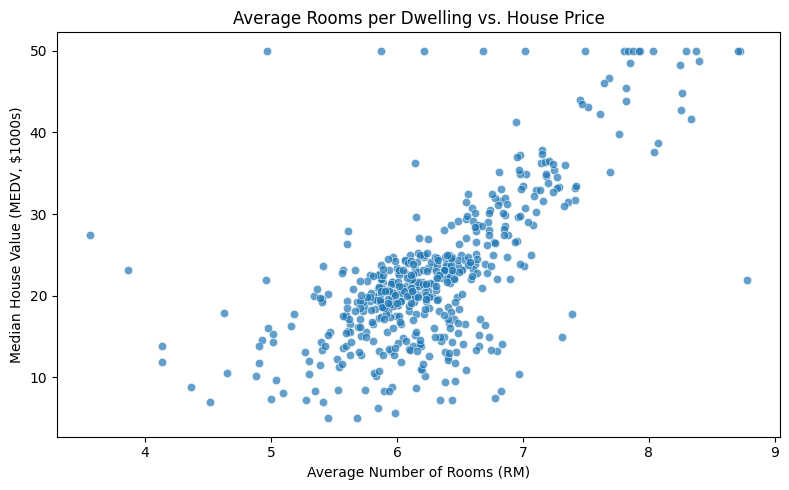

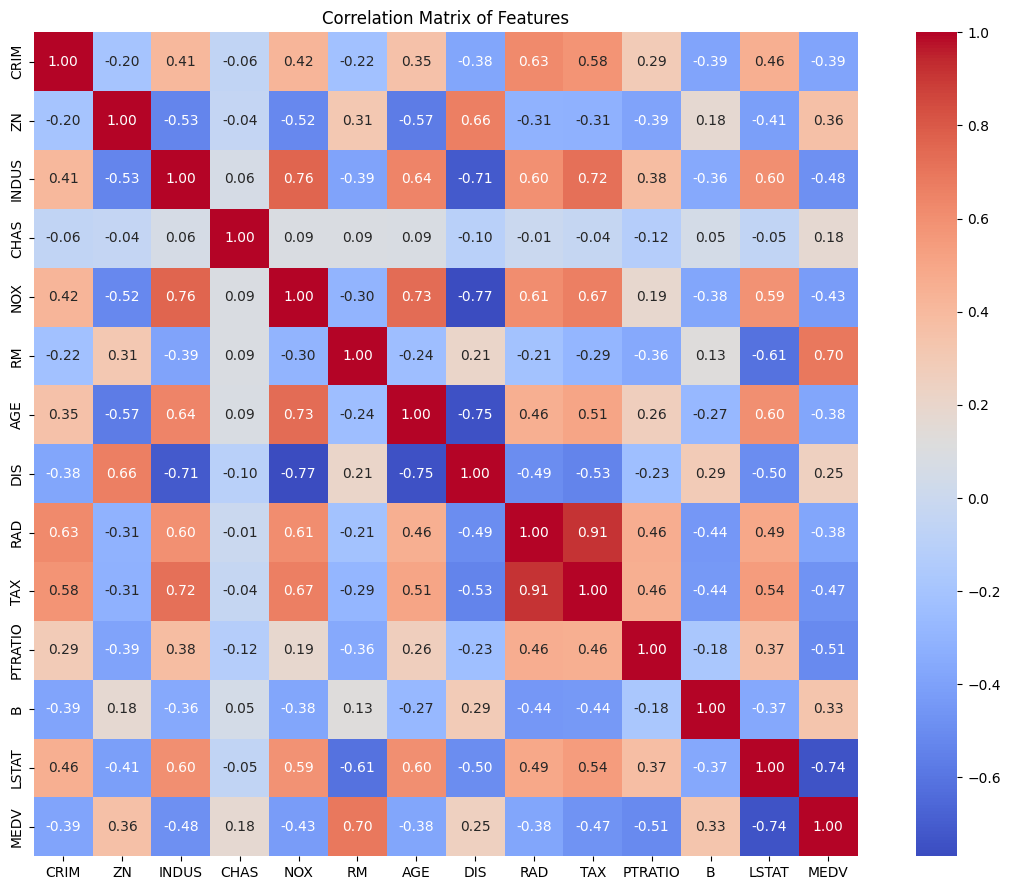


Top correlations with target (MEDV):
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

All EDA plots saved to the 'outputs' folder.


In [20]:
# ===========================================================================
# LEVEL 1 - TASK 2 : EXPLORATORY DATA ANALYSIS (EDA)
# ===========================================================================
section("LEVEL 1 - TASK 2: EXPLORATORY DATA ANALYSIS (EDA)")

# 1. Summary statistics (mean, median, mode, std)
summary_stats = df.describe().T
summary_stats["mode"] = df.mode().iloc[0]
print("\nSummary statistics (mean, std, min, max, mode):")
print(summary_stats[["mean", "50%", "mode", "std", "min", "max"]])

summary_stats.to_csv(os.path.join(OUTPUT_DIR, "summary_statistics.csv"))

# 2. Visualize data distributions - histograms
df.hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Histograms of All Features", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_histograms.png"), dpi=150)
plt.show()

# 3. Boxplots to detect outliers (target variable MEDV as example)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["MEDV"], color="skyblue")
plt.title("Boxplot of Median House Value (MEDV)")
plt.xlabel("MEDV ($1000s)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_boxplot_medv.png"), dpi=150)
plt.show()

# 4. Scatter plot - relationship between RM (rooms) and MEDV (price)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="RM", y="MEDV", alpha=0.7)
plt.title("Average Rooms per Dwelling vs. House Price")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV, $1000s)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_scatter_rm_medv.png"), dpi=150)
plt.show()

# 5. Correlation matrix between numerical features
corr_matrix = df.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_correlation_heatmap.png"), dpi=150)
plt.show()

print("\nTop correlations with target (MEDV):")
print(corr_matrix["MEDV"].sort_values(ascending=False))
print("\nAll EDA plots saved to the 'outputs' folder.")


LEVEL 1 - TASK 3: BASIC DATA VISUALIZATION


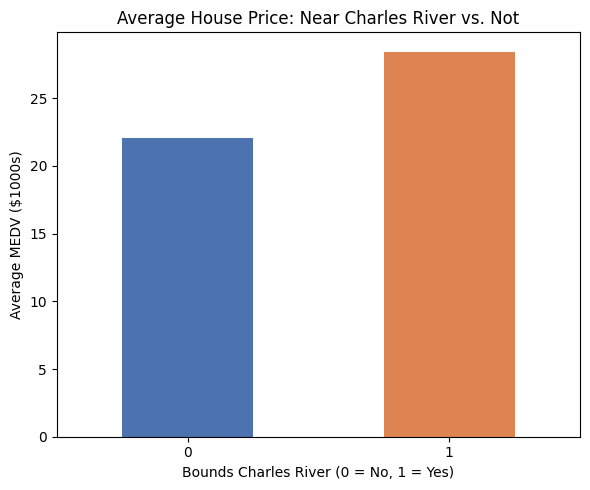

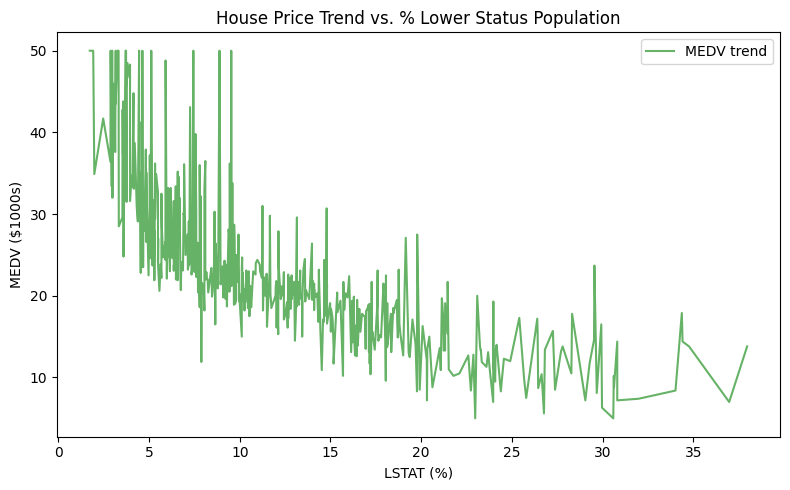

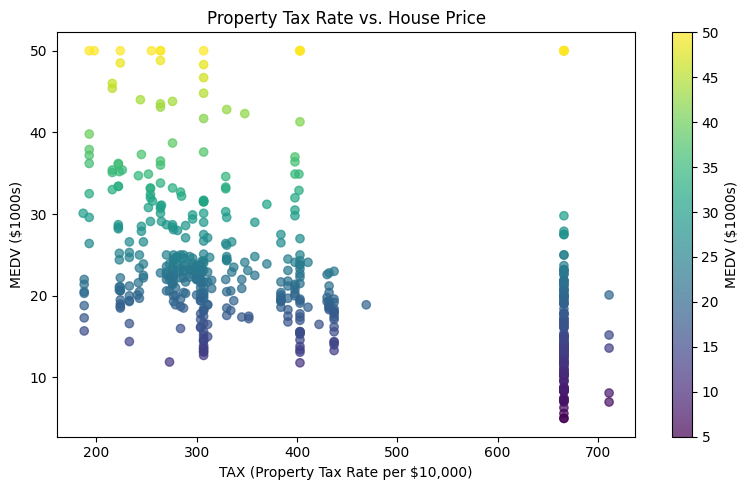

Bar plot, line chart, and scatter plot exported to 'outputs' folder.


In [21]:
# ===========================================================================
# LEVEL 1 - TASK 3 : BASIC DATA VISUALIZATION
# ===========================================================================
section("LEVEL 1 - TASK 3: BASIC DATA VISUALIZATION")

# 1. Bar plot - average MEDV grouped by Charles River proximity (CHAS)
plt.figure(figsize=(6, 5))
avg_by_chas = df.groupby("CHAS")["MEDV"].mean()
avg_by_chas.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Average House Price: Near Charles River vs. Not")
plt.xlabel("Bounds Charles River (0 = No, 1 = Yes)")
plt.ylabel("Average MEDV ($1000s)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "viz_barplot_chas_medv.png"), dpi=150)
plt.show()

# 2. Line chart - MEDV trend sorted by LSTAT (% lower status population)
plt.figure(figsize=(8, 5))
sorted_df = df.sort_values("LSTAT")
plt.plot(sorted_df["LSTAT"], sorted_df["MEDV"], color="green", alpha=0.6)
plt.title("House Price Trend vs. % Lower Status Population")
plt.xlabel("LSTAT (%)")
plt.ylabel("MEDV ($1000s)")
plt.legend(["MEDV trend"])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "viz_linechart_lstat_medv.png"), dpi=150)
plt.show()

# 3. Scatter plot - TAX vs MEDV, customized with labels/title/legend
plt.figure(figsize=(8, 5))
plt.scatter(df["TAX"], df["MEDV"], c=df["MEDV"], cmap="viridis", alpha=0.7)
plt.colorbar(label="MEDV ($1000s)")
plt.title("Property Tax Rate vs. House Price")
plt.xlabel("TAX (Property Tax Rate per $10,000)")
plt.ylabel("MEDV ($1000s)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "viz_scatter_tax_medv.png"), dpi=150)
plt.show()

print("Bar plot, line chart, and scatter plot exported to 'outputs' folder.")
